# LNG Cargo Ageing Simulation — Basics

This notebook demonstrates NeqSim's LNG ageing simulation package for modeling
boil-off gas generation, preferential evaporation, and quality change during
LNG marine transport.

**What you will learn:**
- How to set up a single-tank LNG ageing simulation
- How boil-off rate and composition change over time
- How key quality KPIs (Wobbe Index, GCV, density, Methane Number) evolve
- How to add a voyage profile with varying ambient conditions
- How to configure BOG handling (fuel + reliquefaction)

## 1. Setup and Imports

In [1]:
import importlib, subprocess, sys

try:
    from neqsim_dev_setup import neqsim_init, neqsim_classes
    ns = neqsim_init(recompile=False)
    ns = neqsim_classes(ns)
    NEQSIM_MODE = "devtools"
    print("NeqSim loaded via devtools (local dev mode)")
except Exception:
    try:
        import neqsim
    except ImportError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "neqsim"])
    from neqsim import jneqsim
    NEQSIM_MODE = "pip"
    print("NeqSim loaded via pip package")

NeqSim project root: C:\Users\ESOL\Documents\GitHub\neqsim2
Classpath:
  1. C:\Users\ESOL\Documents\GitHub\neqsim2\target\classes
  2. C:\Users\ESOL\Documents\GitHub\neqsim2\src\main\resources
  3. C:\Users\ESOL\Documents\GitHub\neqsim2\target\neqsim-3.7.0.jar



JVM started: C:\Users\ESOL\graalvm\graalvm-jdk-25.0.1+8.1\bin\server\jvm.dll
Ready — call neqsim_classes(ns) to import classes


All NeqSim classes imported OK
NeqSim loaded via devtools (local dev mode)


In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import jpype
import os

os.makedirs("figures", exist_ok=True)

# Import Java classes (works with both devtools and pip modes)
SystemSrkEos = jpype.JClass("neqsim.thermo.system.SystemSrkEos")
Stream = jpype.JClass("neqsim.process.equipment.stream.Stream")
LNGAgeingScenario = jpype.JClass("neqsim.process.equipment.lng.LNGAgeingScenario")
LNGVoyageProfile = jpype.JClass("neqsim.process.equipment.lng.LNGVoyageProfile")
LNGBOGHandlingNetwork = jpype.JClass("neqsim.process.equipment.lng.LNGBOGHandlingNetwork")
Segment = jpype.JClass("neqsim.process.equipment.lng.LNGVoyageProfile$Segment")

print("All classes imported successfully")

All classes imported successfully


## 2. Define LNG Composition

We use a typical lean LNG composition from Qatar (Qatargas). Temperature is at
the bubble point (~111 K at 1.013 bara). Composition must sum to 1.0.

In [3]:
# Create LNG fluid (temperature in Kelvin, pressure in bara)
lng = SystemSrkEos(111.0, 1.013)
lng.addComponent("methane", 0.912)
lng.addComponent("ethane", 0.055)
lng.addComponent("propane", 0.020)
lng.addComponent("i-butane", 0.005)
lng.addComponent("n-butane", 0.003)
lng.addComponent("nitrogen", 0.005)
lng.setMixingRule("classic")

# Create feed stream
feed = Stream("LNG feed", lng)
feed.setFlowRate(174000.0, "m3/hr")  # Volume for tank sizing
feed.run()

print(f"Feed temperature: {feed.getTemperature() - 273.15:.1f} °C")
print(f"Feed pressure:    {feed.getPressure():.3f} bara")

Feed temperature: -162.1 °C
Feed pressure:    1.013 bara


## 3. Single-Tank Ageing Simulation

We simulate a **Q-Max carrier** (174,000 m³ tank capacity) on a **20-day laden voyage**
from Qatar to Japan. Tank insulation U-value is 0.045 W/(m²·K), typical for
modern membrane containment (GTT Mark III / NO96).

In [4]:
# Configure single-tank ageing scenario
scenario = LNGAgeingScenario("Qatar-Japan Laden", feed)
scenario.setTankVolume(174000.0)         # m3
scenario.setInitialFillingRatio(0.98)    # 98% fill
scenario.setSimulationTime(480.0)        # 20 days = 480 hours
scenario.setTimeStepHours(2.0)           # 2-hour steps for fast demo
scenario.setOverallHeatTransferCoeff(0.045)  # W/(m2·K)
scenario.setAmbientTemperature(308.15)   # 35°C
scenario.setTankPressure(1.013)          # atmospheric

# Run simulation
scenario.run()
results = list(scenario.getResults())
print(f"Simulation complete: {len(results)} time steps")

Simulation complete: 241 time steps


In [5]:
# Extract results into a pandas DataFrame
data = []
for r in results:
    data.append({
        'Time (h)': r.getTimeHours(),
        'Time (days)': r.getTimeHours() / 24.0,
        'Temperature (K)': r.getTemperature(),
        'Temperature (°C)': r.getTemperature() - 273.15,
        'Density (kg/m³)': r.getDensity(),
        'Wobbe Index (MJ/Sm³)': r.getWobbeIndex(),
        'GCV (MJ/Sm³)': r.getGcvVolumetric(),
        'Methane Number': r.getMethaneNumber(),
        'BOR (%/day)': r.getBoilOffRatePctPerDay(),
        'BOG Rate (kg/h)': r.getBogMassFlowRate(),
        'Heat Ingress (kW)': r.getHeatIngressKW(),
        'Liquid Mass (tonnes)': r.getLiquidMass() / 1000.0,
    })
df = pd.DataFrame(data)
df.head(10)

,Time (h),Time (days),Temperature (K),Temperature (°C),Density (kg/m³),Wobbe Index (MJ/Sm³),GCV (MJ/Sm³),Methane Number,BOR (%/day),BOG Rate (kg/h),Heat Ingress (kW),Liquid Mass (tonnes)
0,0.0,0.000000,111.172202,-161.977798,456.412753,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,2.0,0.083333,111.177124,-161.972876,456.412753,55.086324,43.200441,122.809060,0.037406,1212.971036,176.916038,77825.076670
2,4.0,0.166667,111.182047,-161.967953,456.412753,55.086324,43.200441,122.809060,0.037406,1212.940722,176.911617,77822.650788
3,6.0,0.250000,111.186970,-161.963030,456.412740,55.086324,43.200440,122.809060,0.037407,1212.910409,176.907195,77820.224967
4,8.0,0.333333,111.191893,-161.958107,456.413052,55.086338,43.200471,122.809060,0.037407,1212.880092,176.902774,77817.799207
5,10.0,0.416667,111.196816,-161.953184,456.405649,55.086010,43.199739,122.809060,0.037407,1212.849850,176.898352,77815.373510
6,12.0,0.500000,111.201739,-161.948261,456.581340,55.093800,43.217119,122.809060,0.037407,1212.817807,176.893931,77812.947823
7,14.0,0.583333,111.206661,-161.943339,452.396585,54.908923,42.804839,122.809061,0.037409,1212.828487,176.889509,77810.523372
8,16.0,0.666667,111.211589,-161.938411,544.539568,59.291834,52.731270,122.809025,0.037378,1211.799408,176.885088,77808.070826
9,18.0,0.750000,111.216309,-161.933691,701.373912,73.745096,92.846349,122.809711,0.037759,1224.106841,176.880662,77806.163206


## 4. Visualize Key Results

### 4.1 Temperature and Density Profiles

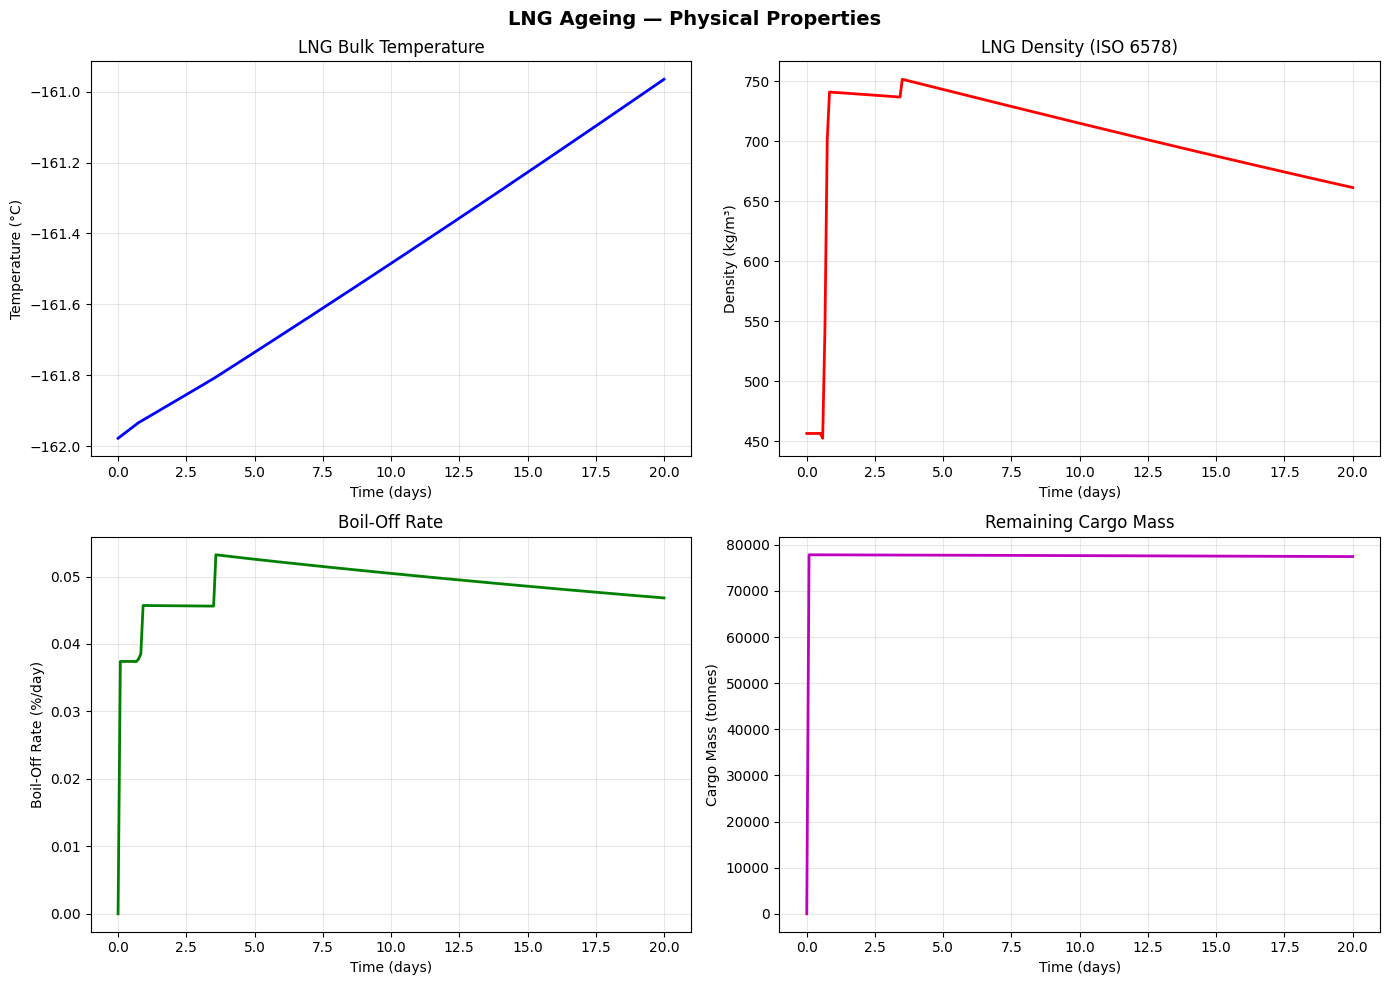

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Temperature
axes[0, 0].plot(df['Time (days)'], df['Temperature (°C)'], 'b-', linewidth=2)
axes[0, 0].set_xlabel('Time (days)')
axes[0, 0].set_ylabel('Temperature (°C)')
axes[0, 0].set_title('LNG Bulk Temperature')
axes[0, 0].grid(True, alpha=0.3)

# Density
axes[0, 1].plot(df['Time (days)'], df['Density (kg/m³)'], 'r-', linewidth=2)
axes[0, 1].set_xlabel('Time (days)')
axes[0, 1].set_ylabel('Density (kg/m³)')
axes[0, 1].set_title('LNG Density (ISO 6578)')
axes[0, 1].grid(True, alpha=0.3)

# BOG Rate
axes[1, 0].plot(df['Time (days)'], df['BOR (%/day)'], 'g-', linewidth=2)
axes[1, 0].set_xlabel('Time (days)')
axes[1, 0].set_ylabel('Boil-Off Rate (%/day)')
axes[1, 0].set_title('Boil-Off Rate')
axes[1, 0].grid(True, alpha=0.3)

# Cargo Mass
axes[1, 1].plot(df['Time (days)'], df['Liquid Mass (tonnes)'], 'm-', linewidth=2)
axes[1, 1].set_xlabel('Time (days)')
axes[1, 1].set_ylabel('Cargo Mass (tonnes)')
axes[1, 1].set_title('Remaining Cargo Mass')
axes[1, 1].grid(True, alpha=0.3)

fig.suptitle('LNG Ageing — Physical Properties', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('figures/lng_physical_properties.png', dpi=150, bbox_inches='tight')
plt.show()

**Discussion:**

- **Observation:** LNG temperature rises gradually as heat ingresses through the tank insulation.
  Density increases as lighter components (nitrogen, methane) evaporate preferentially,
  enriching the liquid in heavier hydrocarbons.
- **Physical mechanism:** The constant heat leak drives evaporation at the liquid surface.
  The latent heat of vaporization absorbs most of the heat, but some goes to sensible
  heating.
- **Engineering implication:** Even a small BOR of 0.10-0.15 %/day results in significant
  cargo loss over a 20-day voyage. Modern membrane tanks target BOR < 0.10 %/day.
- **Recommendation:** Monitor BOR trend — increasing BOR may indicate insulation degradation.

### 4.2 Quality KPIs — Wobbe Index, GCV, and Methane Number

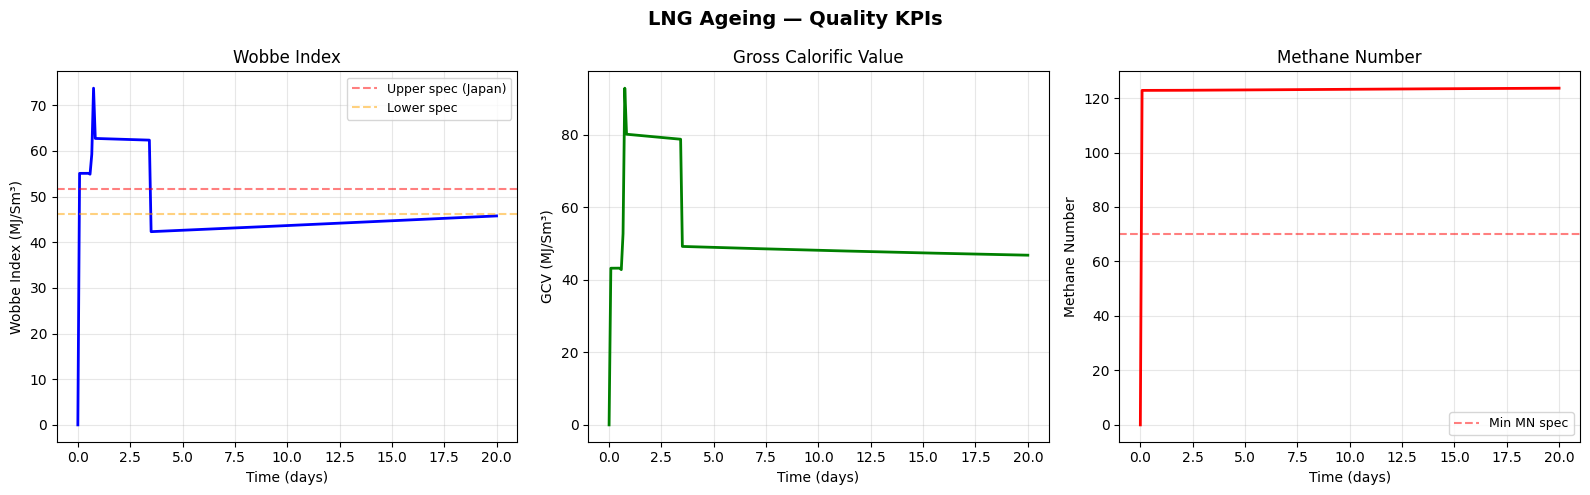

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Wobbe Index
axes[0].plot(df['Time (days)'], df['Wobbe Index (MJ/Sm³)'], 'b-', linewidth=2)
axes[0].axhline(y=51.6, color='r', linestyle='--', alpha=0.5, label='Upper spec (Japan)')
axes[0].axhline(y=46.1, color='orange', linestyle='--', alpha=0.5, label='Lower spec')
axes[0].set_xlabel('Time (days)')
axes[0].set_ylabel('Wobbe Index (MJ/Sm³)')
axes[0].set_title('Wobbe Index')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

# GCV
axes[1].plot(df['Time (days)'], df['GCV (MJ/Sm³)'], 'g-', linewidth=2)
axes[1].set_xlabel('Time (days)')
axes[1].set_ylabel('GCV (MJ/Sm³)')
axes[1].set_title('Gross Calorific Value')
axes[1].grid(True, alpha=0.3)

# Methane Number
axes[2].plot(df['Time (days)'], df['Methane Number'], 'r-', linewidth=2)
axes[2].axhline(y=70, color='r', linestyle='--', alpha=0.5, label='Min MN spec')
axes[2].set_xlabel('Time (days)')
axes[2].set_ylabel('Methane Number')
axes[2].set_title('Methane Number')
axes[2].legend(fontsize=9)
axes[2].grid(True, alpha=0.3)

fig.suptitle('LNG Ageing — Quality KPIs', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('figures/lng_quality_kpis.png', dpi=150, bbox_inches='tight')
plt.show()

**Discussion:**

- **Observation:** Wobbe Index and GCV increase over the voyage as the LNG becomes
  enriched in heavier hydrocarbons. Methane Number decreases.
- **Physical mechanism:** Nitrogen evaporates first (lowest boiling point), then methane.
  This increases the proportion of ethane, propane, and butanes in the liquid.
- **Engineering implication:** At discharge, the LNG may exceed receiving terminal
  Wobbe Index specifications (especially stringent Japanese specs at 51.6 MJ/Sm³ upper limit).
  Falling Methane Number can affect gas engine performance.
- **Recommendation:** Track WI against discharge terminal specs. Consider nitrogen
  ballasting or blending if WI exceeds limits.

### 4.3 Composition Evolution

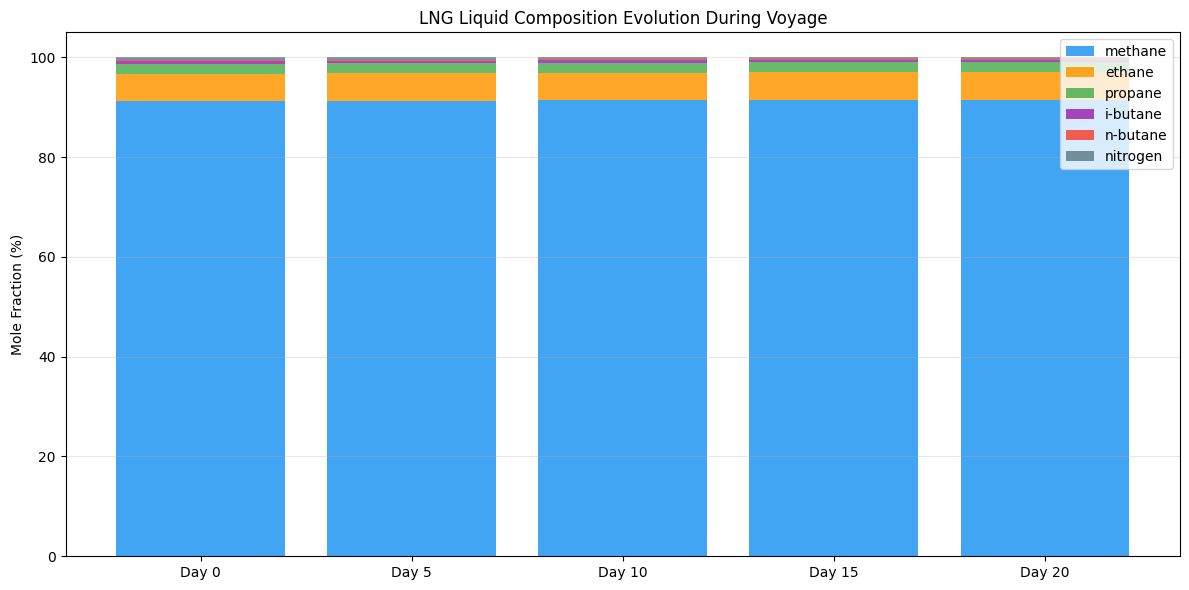


Composition at loading vs discharge:
Time (days)    0.0     20.0
methane     0.91200 0.91535
ethane      0.05500 0.05520
propane     0.02000 0.02007
i-butane    0.00500 0.00484
n-butane    0.00300 0.00170
nitrogen    0.00500 0.00283


In [8]:
# Extract composition at selected time steps
times_to_plot = [0, len(results)//4, len(results)//2, 3*len(results)//4, len(results)-1]
comp_data = []
for idx in times_to_plot:
    r = results[idx]
    comp = dict(r.getLiquidComposition())
    comp['Time (days)'] = r.getTimeHours() / 24.0
    comp_data.append(comp)

comp_df = pd.DataFrame(comp_data)
comp_df = comp_df.set_index('Time (days)')

fig, ax = plt.subplots(figsize=(12, 6))

components = [c for c in comp_df.columns if c != 'Time (days)']
colors = ['#2196F3', '#FF9800', '#4CAF50', '#9C27B0', '#F44336', '#607D8B']

bottom = np.zeros(len(comp_df))
for i, comp_name in enumerate(components):
    values = comp_df[comp_name].values * 100  # Convert to %
    ax.bar(range(len(comp_df)), values, bottom=bottom,
           label=comp_name, color=colors[i % len(colors)], alpha=0.85)
    bottom += values

ax.set_xticks(range(len(comp_df)))
ax.set_xticklabels([f'Day {t:.0f}' for t in comp_df.index])
ax.set_ylabel('Mole Fraction (%)')
ax.set_title('LNG Liquid Composition Evolution During Voyage')
ax.legend(loc='upper right')
ax.set_ylim(0, 105)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('figures/lng_composition_evolution.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nComposition at loading vs discharge:")
print(comp_df.iloc[[0, -1]].T.to_string(float_format='{:.5f}'.format))

**Discussion:**

- **Observation:** Methane fraction decreases while ethane, propane, and butane fractions
  increase. Nitrogen drops rapidly in the first few days.
- **Physical mechanism:** Components evaporate in order of volatility — N₂ first, then C₁,
  then C₂, C₃, etc. This is called "preferential evaporation" or "weathering".
- **Engineering implication:** The BOG is enriched in nitrogen and methane (higher MN, lower
  WI) compared to the liquid. If BOG is used as fuel, engine calibration
  may need adjustment as BOG composition changes over the voyage.
- **Recommendation:** Account for composition drift when sizing BOG handling equipment and
  setting fuel gas specifications.

## 5. Voyage Profile — Varying Ambient Conditions

Real voyages pass through different climate zones. We define a Qatar-to-Japan profile
with decreasing temperature as the ship moves northward.

In [9]:
# Create a new scenario with voyage profile
feed2 = Stream("LNG feed 2", lng)
feed2.setFlowRate(174000.0, "m3/hr")
feed2.run()

scenario2 = LNGAgeingScenario("Qatar-Japan Profiled", feed2)
scenario2.setTankVolume(174000.0)
scenario2.setInitialFillingRatio(0.98)
scenario2.setSimulationTime(480.0)
scenario2.setTimeStepHours(2.0)
scenario2.setOverallHeatTransferCoeff(0.045)
scenario2.setTankPressure(1.013)

# Define voyage segments
profile = LNGVoyageProfile("Qatar to Chita, Japan")
# Segment(startH, endH, ambientTempK, waveHeightM, windSpeedKnots, solarW/m2)
profile.addSegment(Segment(0,    72,  311.15, 0.5,  8.0,  850.0))  # Persian Gulf: 38°C
profile.addSegment(Segment(72,  168,  306.15, 1.5, 15.0,  750.0))  # Arabian Sea: 33°C
profile.addSegment(Segment(168, 288,  303.15, 2.0, 18.0,  600.0))  # Indian Ocean: 30°C
profile.addSegment(Segment(288, 384,  299.15, 2.5, 20.0,  500.0))  # South China Sea: 26°C
profile.addSegment(Segment(384, 480,  291.15, 1.5, 12.0,  350.0))  # East China Sea: 18°C

scenario2.setVoyageProfile(profile)
scenario2.run()

results2 = list(scenario2.getResults())
print(f"Profiled simulation: {len(results2)} time steps")

Profiled simulation: 241 time steps


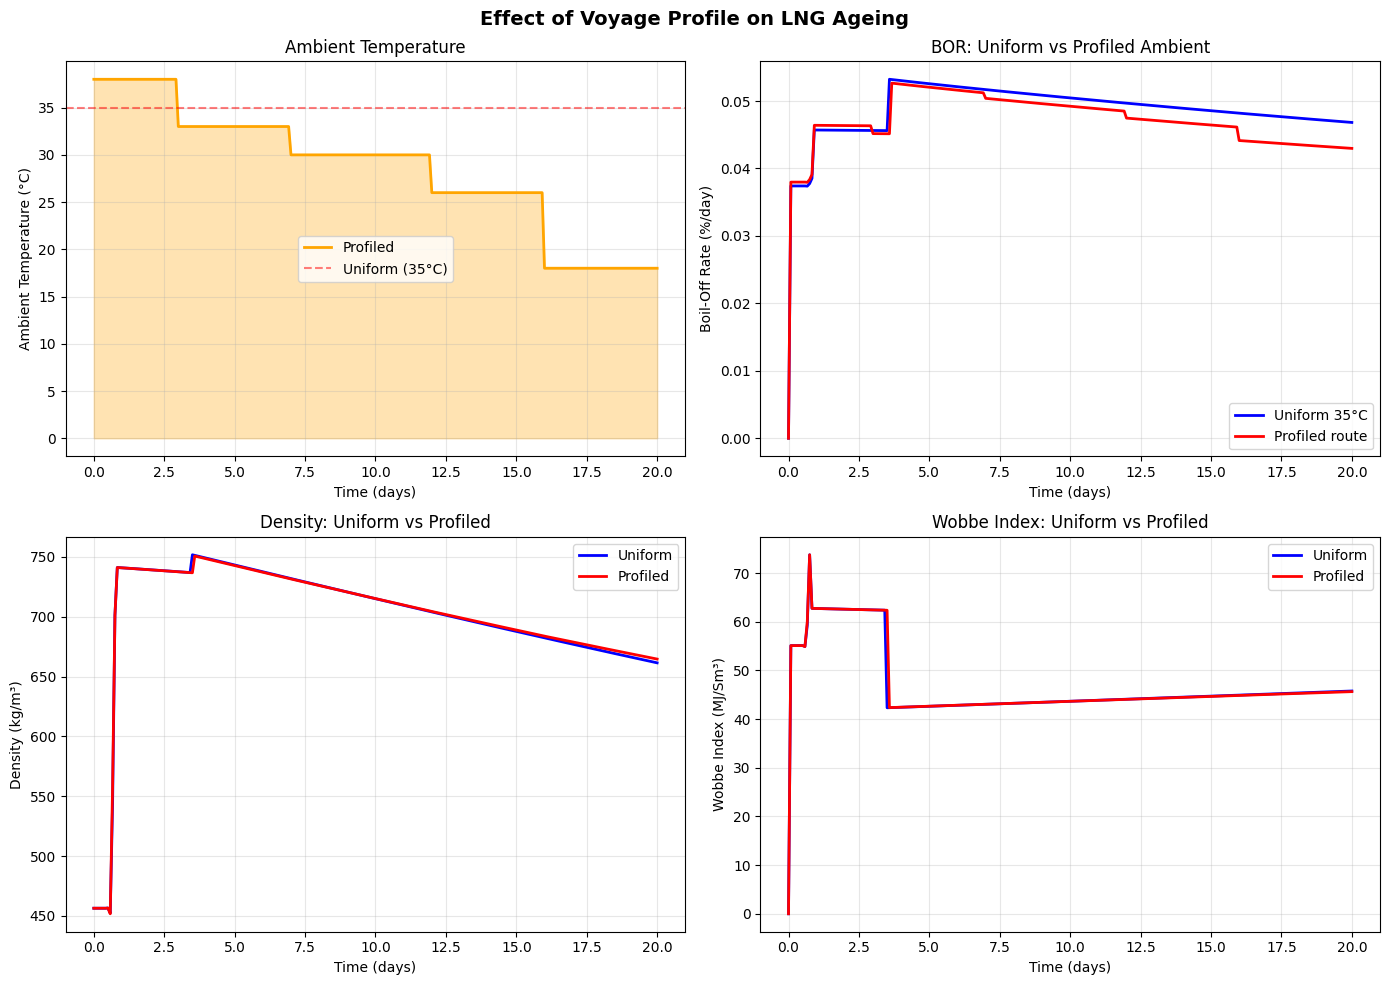

In [10]:
# Compare uniform vs profiled
df2 = pd.DataFrame([{
    'Time (days)': r.getTimeHours() / 24.0,
    'Temperature (°C)': r.getTemperature() - 273.15,
    'Density (kg/m³)': r.getDensity(),
    'Wobbe Index (MJ/Sm³)': r.getWobbeIndex(),
    'BOR (%/day)': r.getBoilOffRatePctPerDay(),
    'Ambient (°C)': r.getAmbientTemperature() - 273.15,
} for r in results2])

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Ambient temperature profile
axes[0, 0].fill_between(df2['Time (days)'], df2['Ambient (°C)'], alpha=0.3, color='orange')
axes[0, 0].plot(df2['Time (days)'], df2['Ambient (°C)'], 'orange', linewidth=2, label='Profiled')
axes[0, 0].axhline(y=35, color='red', linestyle='--', alpha=0.5, label='Uniform (35°C)')
axes[0, 0].set_xlabel('Time (days)')
axes[0, 0].set_ylabel('Ambient Temperature (°C)')
axes[0, 0].set_title('Ambient Temperature')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# BOR comparison
axes[0, 1].plot(df['Time (days)'], df['BOR (%/day)'], 'b-', linewidth=2, label='Uniform 35°C')
axes[0, 1].plot(df2['Time (days)'], df2['BOR (%/day)'], 'r-', linewidth=2, label='Profiled route')
axes[0, 1].set_xlabel('Time (days)')
axes[0, 1].set_ylabel('Boil-Off Rate (%/day)')
axes[0, 1].set_title('BOR: Uniform vs Profiled Ambient')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Density comparison
axes[1, 0].plot(df['Time (days)'], df['Density (kg/m³)'], 'b-', linewidth=2, label='Uniform')
axes[1, 0].plot(df2['Time (days)'], df2['Density (kg/m³)'], 'r-', linewidth=2, label='Profiled')
axes[1, 0].set_xlabel('Time (days)')
axes[1, 0].set_ylabel('Density (kg/m³)')
axes[1, 0].set_title('Density: Uniform vs Profiled')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# WI comparison
axes[1, 1].plot(df['Time (days)'], df['Wobbe Index (MJ/Sm³)'], 'b-', linewidth=2, label='Uniform')
axes[1, 1].plot(df2['Time (days)'], df2['Wobbe Index (MJ/Sm³)'], 'r-', linewidth=2, label='Profiled')
axes[1, 1].set_xlabel('Time (days)')
axes[1, 1].set_ylabel('Wobbe Index (MJ/Sm³)')
axes[1, 1].set_title('Wobbe Index: Uniform vs Profiled')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

fig.suptitle('Effect of Voyage Profile on LNG Ageing', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('figures/lng_voyage_profile_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

**Discussion:**

- **Observation:** The profiled route shows decreasing BOR as the ship moves into cooler
  waters, resulting in slightly less total ageing compared to the uniform 35°C case.
- **Physical mechanism:** Lower ambient temperature reduces the temperature driving force
  (T_ambient - T_LNG) for heat transfer through the insulation, directly reducing BOG.
- **Engineering implication:** Using realistic voyage profiles gives more accurate delivery
  quality predictions. Overestimating ageing (uniform hot ambient) is conservative.
- **Recommendation:** Use actual historical weather data along the route for commercial
  cargo quality guarantees.

## 6. Summary Table

In [11]:
# Create summary table — skip initial zero-state results
# Find first result with non-zero liquid mass (after VLE initialization)
initial = None
for r in results:
    if r.getLiquidMass() > 0:
        initial = r
        break
if initial is None:
    initial = results[1]  # fallback
final = results[-1]

summary = pd.DataFrame({
    'Parameter': [
        'Temperature (°C)', 'Density (kg/m³)', 'Wobbe Index (MJ/Sm³)',
        'GCV (MJ/Sm³)', 'Methane Number', 'BOR (%/day)',
        'Cargo Mass (tonnes)', 'Total BOG (tonnes)'
    ],
    'Loading': [
        f"{initial.getTemperature()-273.15:.2f}",
        f"{initial.getDensity():.1f}",
        f"{initial.getWobbeIndex():.2f}",
        f"{initial.getGcvVolumetric():.2f}",
        f"{initial.getMethaneNumber():.1f}",
        f"{initial.getBoilOffRatePctPerDay():.4f}",
        f"{initial.getLiquidMass()/1000:.0f}",
        '0'
    ],
    'Discharge': [
        f"{final.getTemperature()-273.15:.2f}",
        f"{final.getDensity():.1f}",
        f"{final.getWobbeIndex():.2f}",
        f"{final.getGcvVolumetric():.2f}",
        f"{final.getMethaneNumber():.1f}",
        f"{final.getBoilOffRatePctPerDay():.4f}",
        f"{final.getLiquidMass()/1000:.0f}",
        f"{(initial.getLiquidMass() - final.getLiquidMass())/1000:.0f}"
    ]
})

print("\n" + "="*60)
print("LNG AGEING SIMULATION RESULTS")
print("="*60)
print(summary.to_string(index=False))
print("="*60)

cargo_loss_pct = (1.0 - final.getLiquidMass()/initial.getLiquidMass()) * 100
print(f"\nTotal cargo loss: {cargo_loss_pct:.2f}%")
print(f"Average BOR: {cargo_loss_pct / 20:.4f} %/day")


LNG AGEING SIMULATION RESULTS
           Parameter Loading Discharge
    Temperature (°C) -161.97   -160.97
     Density (kg/m³)   456.4     661.5
Wobbe Index (MJ/Sm³)   55.09     45.76
        GCV (MJ/Sm³)   43.20     46.79
      Methane Number   122.8     123.6
         BOR (%/day)  0.0374    0.0468
 Cargo Mass (tonnes)   77825     77436
  Total BOG (tonnes)       0       389

Total cargo loss: 0.50%
Average BOR: 0.0250 %/day


## 7. Next Steps

- **Advanced features:** See the [LNG Advanced Features](lng_ageing_advanced.ipynb) notebook
  for tank geometry, multi-zone heat transfer, sloshing, rollover detection, and methane number
  calculations.
- **Multi-tank ships:** See [LNG Ship Voyage](lng_ship_voyage.ipynb) for running
  a full Q-Max carrier with 4 tanks and shared BOG handling.